In [1]:
import kagglehub
import os
import cv2
import random
import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
def load_images(folder_path, folder_type, target_size=(128, 128), sample_count=5):
    images = []
    labels = []
    all_filenames = []
    sample_images = []
    sample_labels = []

    if not os.path.isdir(folder_path):
        print(f"Warning: Folder {folder_path} does not exist.")
        return np.array(images), np.array(labels), all_filenames

    print(f"Loading images from subfolders of: {folder_path}")

    for root, _, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    img = load_img(img_path, target_size=target_size)
                    img = img_to_array(img)
                    img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
                    img_array = img / 255.0
                    img_array = np.expand_dims(img_array, axis=-1)

                    if len(sample_images) < sample_count:
                        sample_images.append(img_array)
                        sample_labels.append('Real' if folder_type.lower() == 'real' else 'Forged')

                    images.append(img_array)
                    labels.append(1 if folder_type.lower() == 'real' else 0)
                    all_filenames.append(img_path)
                except Exception as e:
                    print(f"Error processing file {img_path}: {e}")

    if sample_images:
        fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 5))
        for ax, sample_img, sample_label in zip(axes, sample_images, sample_labels):
            ax.imshow(sample_img.squeeze(), cmap='gray')
            ax.set_title(sample_label, fontsize=10)  # Use label instead of filename
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    print(f"Total images loaded: {len(images)}")
    return np.array(images), np.array(labels), all_filenames

In [12]:
path = kagglehub.dataset_download("tienen/handwritten-signature-verification")

In [13]:
# ...existing code...

f_data = "/kaggle/input/handwritten-signature-verification/data/data/forged"
r_data = "/kaggle/input/handwritten-signature-verification/data/data/real"

# ...existing code...

Loading images from subfolders of: /kaggle/input/handwritten-signature-verification/data/data/forged
Error processing file /kaggle/input/handwritten-signature-verification/data/data/forged/ru.d1c664d6-431d-4985-9e21-5989b1b7df4b__0001e12109--61ff34f8f73c4b173c32986d__JP A.jpg: cannot identify image file <_io.BytesIO object at 0x7c865a214cc0>


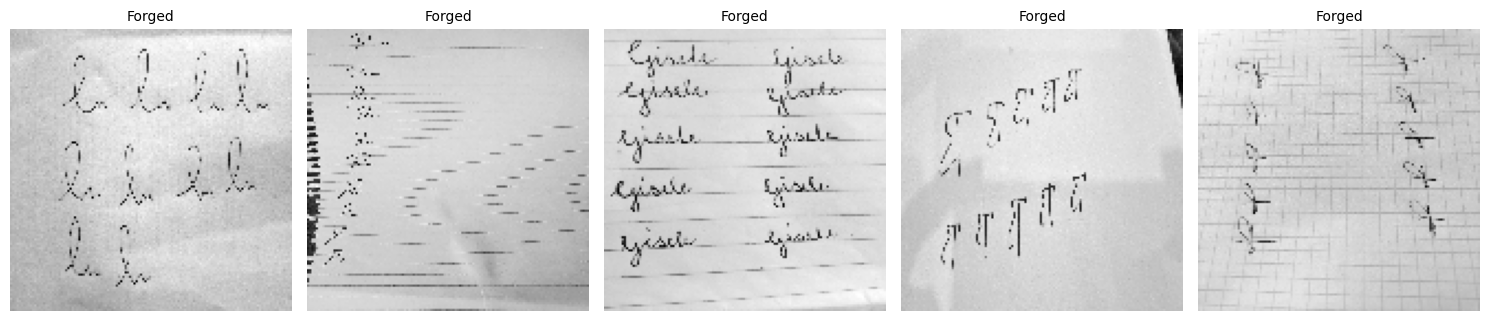

Total images loaded: 2983
Loading images from subfolders of: /kaggle/input/handwritten-signature-verification/data/data/real


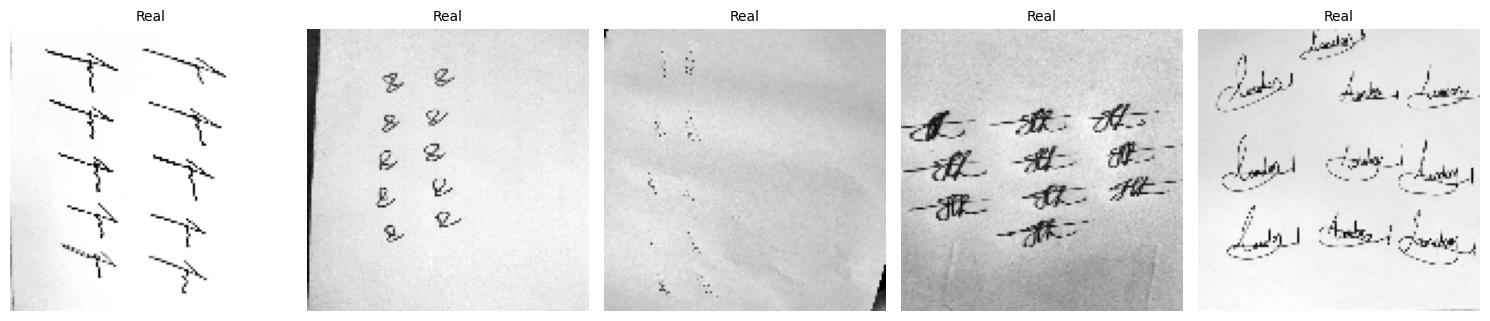

Total images loaded: 3188


In [14]:
imgs_f, labels_f, k = load_images(f_data, "forged")
imgs_r, labels_r, l = load_images(r_data, "real")

In [15]:
all_images = np.concatenate((imgs_f, imgs_r), axis=0)
all_labels = np.concatenate((labels_f, labels_r), axis=0)


all_images, all_labels = shuffle(all_images, all_labels, random_state=42)

In [16]:
all_labels = to_categorical(all_labels,num_classes = 2)

In [17]:
all_labels.shape

(6171, 2)

In [18]:
all_images.shape

(6171, 128, 128, 1)

In [19]:
x_train, x_test, y_train, y_test = train_test_split(all_images, all_labels, test_size=0.3, random_state=42)

In [20]:
print(x_train.shape)
x_test.shape

(4319, 128, 128, 1)


(1852, 128, 128, 1)

In [21]:
train_datagen = ImageDataGenerator(
    rotation_range=35,
    width_shift_range=0.3,
    height_shift_range=0.2,
    shear_range=0.3,
    horizontal_flip=True,
)


train_generator = train_datagen.flow(x_train, y_train, batch_size=128)

In [22]:
def plot_train(hist):
    history = hist.history

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    axes[0].plot(history['loss'], label='Training Loss')
    axes[0].plot(history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss Over Epochs')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid()

    if 'accuracy' in history:  # Adjust for older versions with 'acc'
        axes[1].plot(history['accuracy'], label='Training Accuracy')
        axes[1].plot(history['val_accuracy'], label='Validation Accuracy')
        axes[1].set_title('Model Accuracy Over Epochs')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid()


    plt.tight_layout()
    plt.show()

In [23]:
base_model = ResNet50(include_top=False, weights=None, input_shape=(128, 128, 1))

for layer in base_model.layers[:30]:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu',kernel_regularizer= tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu',kernel_regularizer= tf.keras.regularizers.l2(0.01))(x)
predictions = Dense(2, activation='softmax')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=predictions)


In [24]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=(x_test,y_test),
    epochs=25,
    callbacks=[early_stopping],
    batch_size = 128
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.4958 - loss: 4.7564 - val_accuracy: 0.5049 - val_loss: 4.4643
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 348ms/step - accuracy: 0.5025 - loss: 4.3886 - val_accuracy: 0.4951 - val_loss: 4.1317
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 389ms/step - accuracy: 0.5239 - loss: 4.0535 - val_accuracy: 0.4951 - val_loss: 3.8322
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 360ms/step - accuracy: 0.5450 - loss: 3.7465 - val_accuracy: 0.4951 - val_loss: 3.5567
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 365ms/step - accuracy: 0.5676 - loss: 3.4643 - val_accuracy: 0.4951 - val_loss: 3.3514
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 358ms/step - accuracy: 0.5667 - loss: 3.2061 - val_accuracy: 0.4951 - val_loss: 3.1197
Epoch 7/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 355ms/step - accuracy: 0.5681 - loss: 2.9704 - val_accuracy: 0.4951 - val_loss: 2.9200
Epoch 8/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 351ms/step - accuracy: 0.5654 - loss: 2.7625 - val_accura

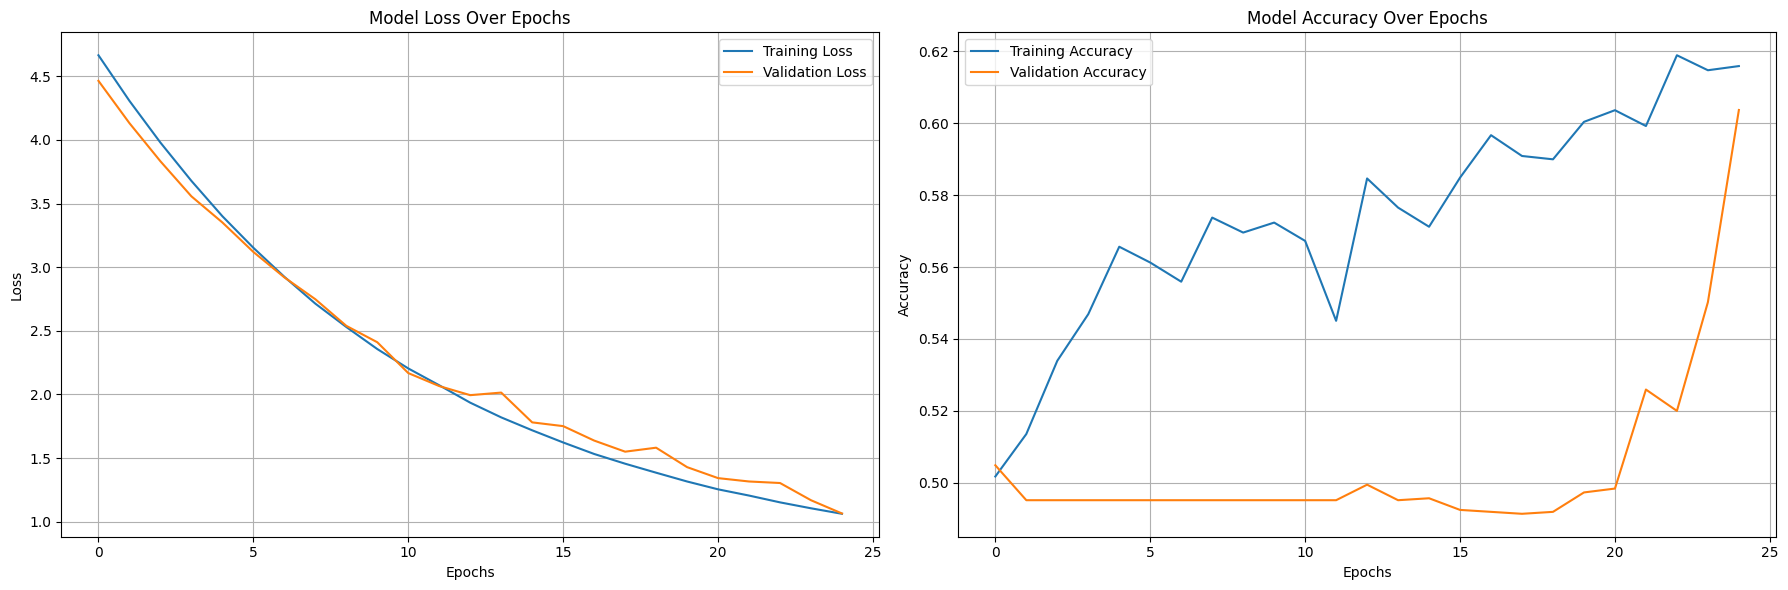

In [25]:
plot_train(history)

In [26]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile the model after unfreezing
model.compile(optimizer=Adam(learning_rate=0.00001),  # Lower learning rate for fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_tuned = model.fit(
    train_generator,
    validation_data=(x_test,y_test),
    epochs=100,
    callbacks=[early_stopping],
    batch_size = 128
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6133 - loss: 1.0424 - val_accuracy: 0.6048 - val_loss: 1.0664
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - accuracy: 0.6312 - loss: 1.0305 - val_accuracy: 0.6075 - val_loss: 1.0470
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 374ms/step - accuracy: 0.6462 - loss: 1.0021 - val_accuracy: 0.6156 - val_loss: 1.0338
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 357ms/step - accuracy: 0.6439 - loss: 0.9972 - val_accuracy: 0.6269 - val_loss: 1.0153
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 354ms/step - accuracy: 0.6611 - loss: 0.9746 - val_accuracy: 0.6220 - val_loss: 1.0114
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 356ms/step - accuracy: 0.6394 - loss: 0.9921 - val_accuracy: 0.6393 - val_loss: 0.9878
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 359ms/step - accuracy: 0.6740 - loss: 0.9616 - val_accuracy: 0.6409 - val_loss: 0.9751
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 359ms/step - accuracy: 0.6553 - loss: 0.9629 - val

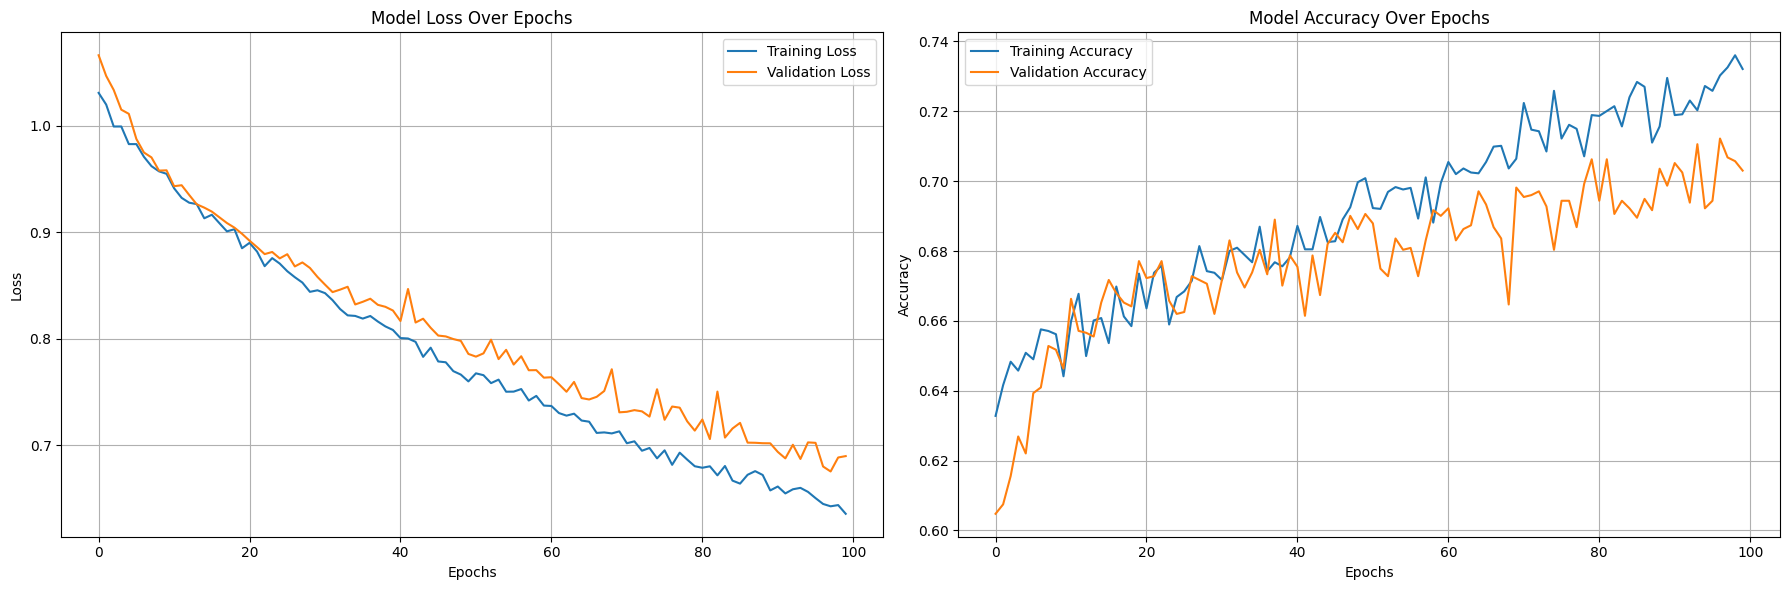

In [27]:
plot_train(history_tuned)

In [28]:
# creating more complex augemtation to prevent over fitting
train_datagen = ImageDataGenerator(
    rotation_range=35,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.4,
    horizontal_flip=True,
)


train_generator = train_datagen.flow(x_train, y_train, batch_size=64)

In [29]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile the model after unfreezing
model.compile(optimizer=Adam(learning_rate=0.00001),  # Lower learning rate for fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model with early stopping
history_tuned = model.fit(
    train_generator,
    validation_data=(x_test,y_test),
    epochs=100,
    callbacks=[early_stopping],
    batch_size = 64
)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 96s 628ms/step - accuracy: 0.7124 - loss: 0.6607 - val_accuracy: 0.7090 - val_loss: 0.6751
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 209ms/step - accuracy: 0.7169 - loss: 0.6676 - val_accuracy: 0.7036 - val_loss: 0.6823
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.7259 - loss: 0.6445 - val_accuracy: 0.7095 - val_loss: 0.6813
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 210ms/step - accuracy: 0.7134 - loss: 0.6599 - val_accuracy: 0.7122 - val_loss: 0.6753
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 209ms/step - accuracy: 0.7249 - loss: 0.6411 - val_accuracy: 0.6998 - val_loss: 0.6833
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 191ms/step - accuracy: 0.7050 - loss: 0.6513 - val_accuracy: 0.6863 - val_loss: 0.7171
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 211ms/step - accuracy: 0.7271 - loss: 0.6412 - val_accuracy: 0.7052 - val_loss: 0.6719
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.7176 - loss: 0.6350 - 

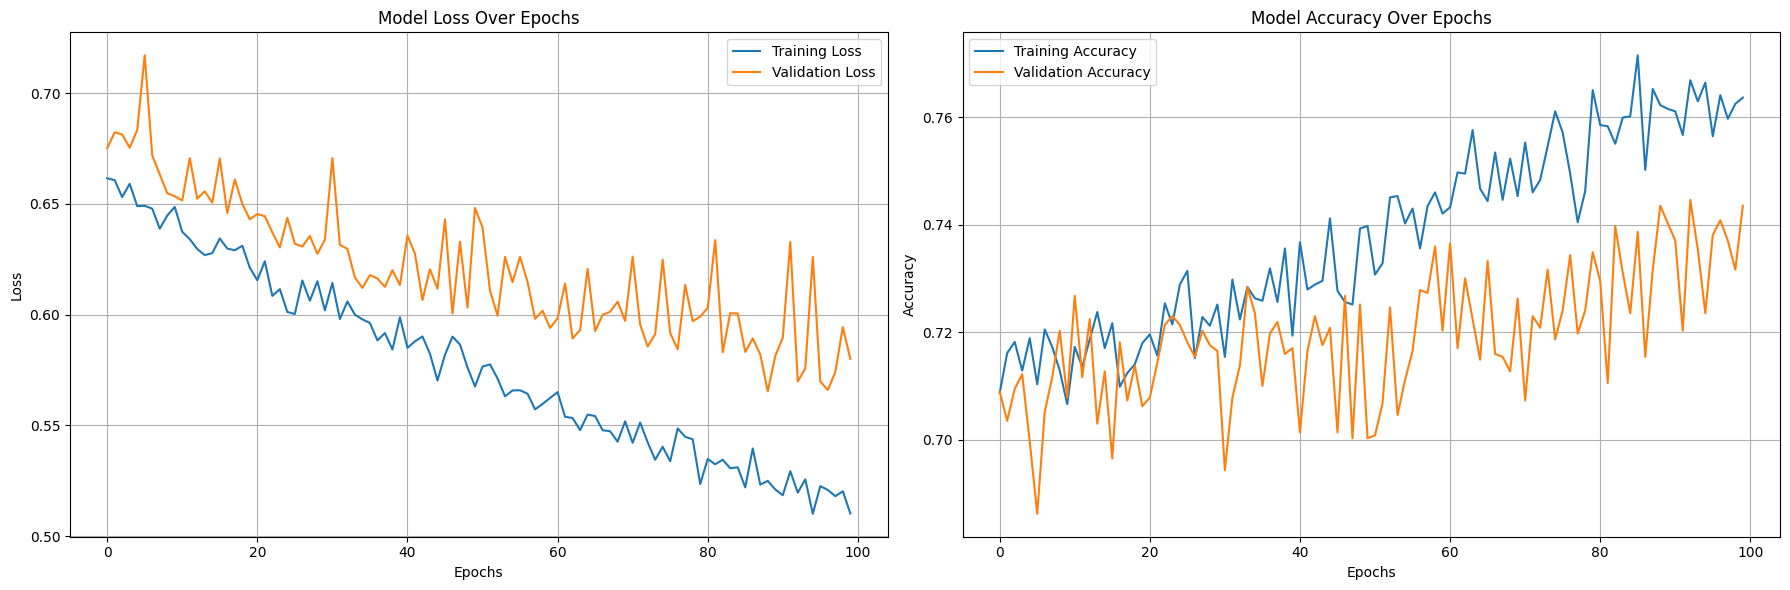

In [30]:
plot_train(history_tuned)

In [31]:
model.evaluate(x_test,y_test)

58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.7444 - loss: 0.5753


[0.5653721690177917, 0.7435204982757568]

In [ ]:
model.save('fr.h5')
from IPython.display import FileLink
FileLink('fr.h5')

/content/fr.h5

In [33]:

model.save("/home/model/model.keras")